In [6]:
# from src.MPOptoClass import *
from src.utils.gen_utils import *
from src.utils.filters import *
from src.experiment import *
from src.wiener_filter import *
from src.modeller import *
from src.MPRecordClass import *
from src.ReachingClass import *
from src.analysis import *
import scipy
import copy
import time
import mat73 
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import random
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from itertools import permutations, compress, product
from tqdm import tqdm
import joblib
from rrpy import ReducedRankRidge
import seaborn as sns
from src.plotter import *
import math




%load_ext autoreload 
%autoreload 2
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# slightly redone cosweepresgsALL

In [15]:
output = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsAll_5nlag_50post_50sw.pickle')
asymps = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsAllasymps_5nlag_50post_50sw.pickle')

In [16]:
binsize=5
nlags=5
post=50
pre=100
num_PCs=20

In [339]:
i_cc_list=[]
i_cl_list=[]

i_swc_list=[]
i_swl_list=[]

ui_cc_list=[]
ui_cl_list=[]

ui_swc_list=[]
ui_swl_list=[]

cc_slope = []
swl_slope = []
for sesh in tqdm(np.arange(len(output))):
    cc_r2 = []
    cl_r2 = []
    c_ratio = []
    c_hlist = []

    swc_r2=[]
    swl_r2=[]
    sw_ratio=[]
    sw_hlist=[]

    cwc_r2=[]
    cwl_r2=[]
    cw_ratio=[]
    cw_hlist=[]

    lc_r2 = []
    ll_r2=[]
    l_ratio=[]
    l_hlist=[]
    regs=[]

    cl_pos_asymps = asymps[sesh][0][0][0]
    cc_pos_asymps = asymps[sesh][0][0][1]
    
    cl_neg_asymps = asymps[sesh][0][1][0]
    cc_neg_asymps = asymps[sesh][0][1][1]
    
    swl_pos_asymps = asymps[sesh][1][0][0]
    swc_pos_asymps = asymps[sesh][1][0][1]
    
    swl_neg_asymps = asymps[sesh][1][1][0]
    swc_neg_asymps = asymps[sesh][1][1][1]
    
    cwl_pos_asymps = asymps[sesh][2][0][0]
    cwc_pos_asymps = asymps[sesh][2][0][1]
    
    cwl_neg_asymps = asymps[sesh][2][1][0]
    cwc_neg_asymps = asymps[sesh][2][1][1]
    
    ll_pos_asymps = asymps[sesh][3][0][0]
    lc_pos_asymps = asymps[sesh][3][0][1]
    
    ll_neg_asymps = asymps[sesh][3][1][0]
    lc_neg_asymps = asymps[sesh][3][1][1]
   
    X_l = asymps[sesh][4][0]
    X_c = asymps[sesh][4][1]

    Y_l = asymps[sesh][5][0]
    Y_c = asymps[sesh][5][1]
    
    i_cc_list.append(cc_neg_asymps)
    i_cl_list.append(cl_neg_asymps)
    i_swc_list.append(swc_neg_asymps)
    i_swl_list.append(swl_neg_asymps)

    session_name = output[sesh][0][4][1]
    inact = output[sesh][0][4][2]

    animal = session_name.split('_')[0]
    session_path = f'../data/co/{animal}/{session_name}'
    session = MPOptoClass(session_path)


    #divg_laser_bounds, divg_ctrl_bounds = session.adjustLaserBounds(pre=0, post=50, only_climb=True)
    
    #dnstr_dvg=[]
    #upstr_dvg=[]
    
    #(X, Y), PCs = session.generate_trainset(bounds=session.climbing_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
    #dnstr_l, upstr_l = session.binner(bounds=divg_laser_bounds, binsize=binsize, concat=True) 
    #dnstr_c, upstr_c = session.binner(bounds=divg_ctrl_bounds, binsize=binsize, concat=True) 
    
    #dnstr_dvg.append(divergence(dnstr_c, dnstr_l, PCAObject=PCs[0]))
    #print(dnstr_dvg[-1])
    #upstr_dvg.append(divergence(upstr_c, upstr_l, PCAObject=PCs[1]))
    #print(upstr_dvg[-1])
    

    num_laser_samples = int((post+25) / binsize)

    print(session_name)
    print(inact)
    for run in output[sesh]:
 

        c=run[0]
        sw=run[1]
        cw = run[2]
        l = run[3]

        regs.append(run[2][0])

        c_hlist.append(c[0])
        cl_r2.append(c[1])
        cc_r2.append(c[2])
        d, u = session.weights_per_region(c_hlist[-1], nlags=nlags, num_region1=20)
        c_ratio.append(np.log10(d/u))

        sw_hlist.append(sw[0])
        swl_r2.append(sw[1])
        swc_r2.append(sw[2])
        d, u = session.weights_per_region(sw_hlist[-1], nlags=nlags, num_region1=20)
        sw_ratio.append(np.log10(d/u))

        cw_hlist.append(cw[0])
        cwl_r2.append(cw[1])
        cwc_r2.append(cw[2])
        d, u = session.weights_per_region(cw_hlist[-1], nlags=nlags, num_region1=20)
        cw_ratio.append(np.log10(d/u))

        l_hlist.append(l[0])
        ll_r2.append(l[1])
        lc_r2.append(l[2])
        d, u = session.weights_per_region(l_hlist[-1], nlags=nlags, num_region1=20)
        l_ratio.append(np.log10(d/u))
        
    ctop_ratio, ctop_r2, cidxs, cedges = get_top_models(c_ratio, cc_r2, num_bins=10)
    swtop_ratio, swtop_r2, swidxs, _ = get_top_models(sw_ratio, swl_r2, num_bins=10)

    idx_cmax = np.argmax(ctop_r2)
    idx_swmax = np.argmax(swtop_r2)
    
            
    ctop_ratio_fp = ctop_ratio[idx_cmax:]
    ctop_r2_fp = ctop_r2[idx_cmax:]
    
    temp_x=[]
    temp_y=[]
    
    temp_x.append(ctop_ratio[idx_swmax])
    temp_y.append(ctop_r2[idx_swmax])
        
    temp_list=[]
    for idx, temp in enumerate(ctop_r2_fp):
        if math.isclose(cc_pos_asymps, temp, rel_tol=.03):
            if idx==0:
                print('slope of 0')
                cc_slope.append(0)
                break
            else:
                print(f'cc:{idx}')
                temp_x.append(ctop_ratio_fp[idx])
                temp_y.append(temp)
                linr = scipy.stats.linregress(temp_x, temp_y)
                cc_slope.append(linr.slope)
                break
            

 
        
    swtop_ratio_fp = swtop_ratio[idx_swmax:]
    swtop_r2_fp = swtop_r2[idx_swmax:]
    
    temp_x=[]
    temp_y=[]
    
    temp_x.append(swtop_ratio[idx_swmax])
    temp_y.append(swtop_r2[idx_swmax])
        
    temp_list=[]
    for idx, temp in enumerate(swtop_r2_fp):
        if math.isclose(swl_pos_asymps, temp, rel_tol=.03):
            if idx==0:
                swl_slope.append(0)
                break
            else:
                temp_x.append(swtop_ratio_fp[idx])
                temp_y.append(temp)
                linr = scipy.stats.linregress(temp_x, temp_y)
                swl_slope.append(linr.slope)
                break
            

        
        
        
        
    all_ccmax = np.max(cc_r2)
    all_clmax = np.max(cl_r2)
    all_swcmax = np.max(swc_r2)
    all_swlmax = np.max(swl_r2)
    all_cwcmax = np.max(cwc_r2)
    all_cwlmax = np.max(cwl_r2)
    all_lcmax = np.max(lc_r2)
    all_llmax = np.max(ll_r2)
    
    ui_cc_list.append(all_ccmax - cc_pos_asymps)
    ui_cl_list.append(all_clmax - cl_pos_asymps)
    ui_swc_list.append(all_swcmax - swc_pos_asymps)
    ui_swl_list.append(all_swlmax - swl_pos_asymps)
    
    
    
    

  8%|██████▍                                                                             | 1/13 [00:00<00:10,  1.19it/s]

love
co10_01232024
RFA
[-0.54457513  0.10573206  0.34723606  0.84506622  1.5055283   2.21830988
  2.94276727  3.12947206  3.66950905  4.39668218]
[-0.50117656  0.0301254   0.2002868   0.59372597  1.12503092  1.70303288
  2.36906311  2.55137304  3.08189209  3.80633178]
slope of 0


 15%|████████████▉                                                                       | 2/13 [00:01<00:08,  1.25it/s]

love
co10_01252024
RFA
[-0.57879127 -0.02662068  0.04495646  0.75776432  1.3972331   2.1032093
  2.82622109  2.9800362   3.55268485  4.27980561]
[-0.46907036 -0.01736851  0.55821277  0.64447528  1.15508898  1.84697295
  2.56680441  3.12313249  3.29264079  4.01964328]
cc:2


 23%|███████████████████▍                                                                | 3/13 [00:02<00:08,  1.17it/s]

...

love
co9_12142023
CFA
[-0.67087313 -0.07473261  0.0683677   0.76200608  1.38821018  2.15499408
  2.18105592  2.87691418  3.60316498  4.33024554]
[-0.62391921 -0.15203789  0.03863582  0.5258569   1.01110396  1.69777078
  2.41647653  2.95136795  3.14210602  3.86906942]
cc:3


 92%|████████████████████████████████████████████████████████████████████████████▌      | 12/13 [00:09<00:00,  1.19it/s]

love
co9_12132023
CFA
[-0.4577473   0.10905812  0.41951259  0.72045745  1.34859152  2.05315632
  2.77596252  2.91185504  3.50239067  4.22950484]
[-0.40939862 -0.02380593  0.29263146  0.81781719  1.09304012  1.63908588
  2.35264107  2.91971884  3.07726379  3.80403702]
slope of 0


100%|███████████████████████████████████████████████████████████████████████████████████| 13/13 [00:10<00:00,  1.26it/s]

love
co9_12152023
CFA
[-0.38382011  0.07630073  0.48796092  1.00609577  1.47491904  1.6626936
  2.1852075   2.90913487  3.09763718  3.63577441]
[-3.13791672e-01 -2.14397826e-03  4.37441270e-01  6.74883728e-01
  1.19828178e+00  1.57571878e+00  1.80476407e+00  2.26756560e+00
  2.98736589e+00  3.21527938e+00]
slope of 0


In [340]:
cc_slope

[0,
 -0.006740092766976117,
 0,
 0,
 -0.009634236858226746,
 0,
 0,
 0.0004997293848457202,
 -0.008891677066455324,
 -0.006614764855468368,
 -0.004120976708707968,
 0,
 0]

In [342]:
swl_slope

[-0.01855396992869667,
 -0.036638922458860496,
 -0.01049974896490511,
 0,
 -0.010885844821844787,
 -0.011664044942786814,
 -0.011242609955708105,
 -0.03408168196722858,
 -0.02953650502030425,
 -0.027124745715752074,
 -0.013036485888476942]

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


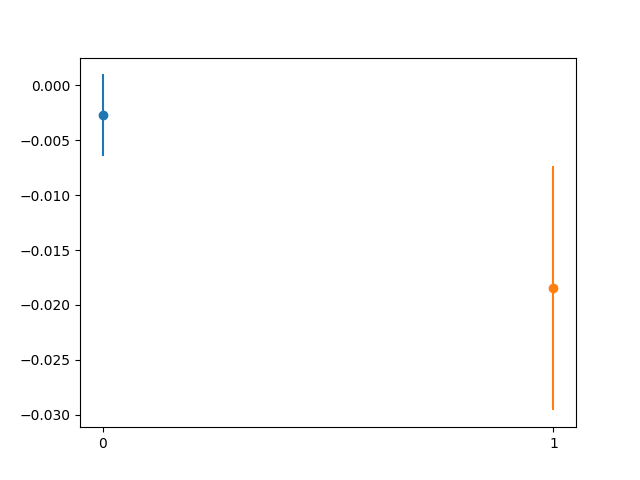

In [343]:
fig, ax = plt.subplots()
ax = plot_avgstd('0', cc_slope, ax=ax)
ax = plot_avgstd('1', swl_slope, ax=ax)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


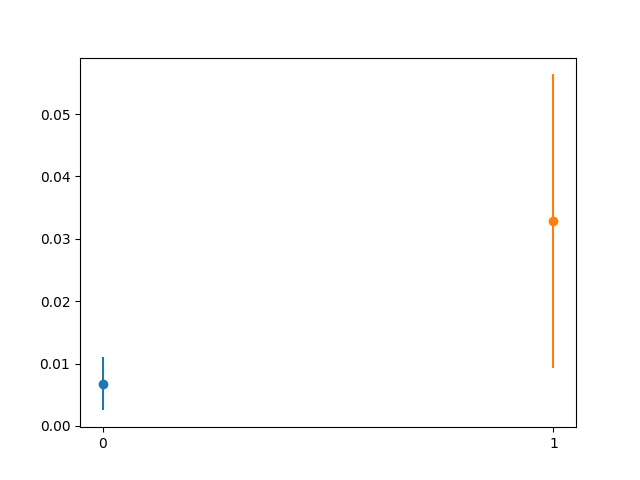

In [288]:
fig, ax = plt.subplots()
ax = plot_avgstd('0', ui_cc_list, ax=ax)
ax = plot_avgstd('1', ui_swl_list, ax=ax)

In [319]:
diff_l =[]
diff_c=[]
laser_r2max=[]
sw_r2max=[]
sesh=4
cc_r2 = []
cl_r2 = []
c_ratio = []
c_hlist = []

swc_r2=[]
swl_r2=[]
sw_ratio=[]
sw_hlist=[]

cwc_r2=[]
cwl_r2=[]
cw_ratio=[]
cw_hlist=[]

lc_r2 = []
ll_r2=[]
l_ratio=[]
l_hlist=[]
regs=[]

cl_pos_asymps = asymps[sesh][0][0][0]
cc_pos_asymps = asymps[sesh][0][0][1]

cl_neg_asymps = asymps[sesh][0][1][0]
cc_neg_asymps = asymps[sesh][0][1][1]

swl_pos_asymps = asymps[sesh][1][0][0]
swc_pos_asymps = asymps[sesh][1][0][1]

swl_neg_asymps = asymps[sesh][1][1][0]
swc_neg_asymps = asymps[sesh][1][1][1]

cwl_pos_asymps = asymps[sesh][2][0][0]
cwc_pos_asymps = asymps[sesh][2][0][1]

cwl_neg_asymps = asymps[sesh][2][1][0]
cwc_neg_asymps = asymps[sesh][2][1][1]

ll_pos_asymps = asymps[sesh][3][0][0]
lc_pos_asymps = asymps[sesh][3][0][1]

ll_neg_asymps = asymps[sesh][3][1][0]
lc_neg_asymps = asymps[sesh][3][1][1]

X_l = asymps[sesh][4][0]
X_c = asymps[sesh][4][1]

Y_l = asymps[sesh][5][0]
Y_c = asymps[sesh][5][1]

session_name = output[sesh][0][4][1]
inact = output[sesh][0][4][2]

animal = session_name.split('_')[0]
session_path = f'../data/co/{animal}/{session_name}'
session = MPOptoClass(session_path)


divg_laser_bounds, divg_ctrl_bounds = session.adjustLaserBounds(pre=0, post=50, only_climb=True)

dnstr_dvg=[]
upstr_dvg=[]

#(X, Y), PCs = session.generate_trainset(bounds=session.climbing_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
#dnstr_l, upstr_l = session.binner(bounds=divg_laser_bounds, binsize=binsize, concat=True) 
#dnstr_c, upstr_c = session.binner(bounds=divg_ctrl_bounds, binsize=binsize, concat=True) 

#dnstr_dvg.append(divergence(dnstr_c, dnstr_l, PCAObject=PCs[0]))
#print(dnstr_dvg[-1])
#upstr_dvg.append(divergence(upstr_c, upstr_l, PCAObject=PCs[1]))
#print(upstr_dvg[-1])


num_laser_samples = int((post+25) / binsize)

print(session_name)
print(inact)
for run in output[sesh]:


    c=run[0]
    sw=run[1]
    cw = run[2]
    l = run[3]

    regs.append(run[2][0])

    c_hlist.append(c[0])
    cl_r2.append(c[1])
    cc_r2.append(c[2])
    d, u = session.weights_per_region(c_hlist[-1], nlags=nlags, num_region1=20)
    c_ratio.append(np.log10(d/u))

    sw_hlist.append(sw[0])
    swl_r2.append(sw[1])
    swc_r2.append(sw[2])
    d, u = session.weights_per_region(sw_hlist[-1], nlags=nlags, num_region1=20)
    sw_ratio.append(np.log10(d/u))

    cw_hlist.append(cw[0])
    cwl_r2.append(cw[1])
    cwc_r2.append(cw[2])
    d, u = session.weights_per_region(cw_hlist[-1], nlags=nlags, num_region1=20)
    cw_ratio.append(np.log10(d/u))

    l_hlist.append(l[0])
    ll_r2.append(l[1])
    lc_r2.append(l[2])
    d, u = session.weights_per_region(l_hlist[-1], nlags=nlags, num_region1=20)
    l_ratio.append(np.log10(d/u))
    


all_swmax = np.argmax(swl_r2)
diff_l.append(np.abs(swc_r2[all_swmax]-swl_r2[all_swmax]))

all_cmax = np.argmax(cc_r2)
diff_c.append(np.abs(cc_r2[all_cmax]-cl_r2[all_cmax]))

laser_r2max.append(np.max(ll_r2))
sw_r2max.append(np.max(swl_r2))

co12 handfix lol
love
co12_02132024
RFA


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


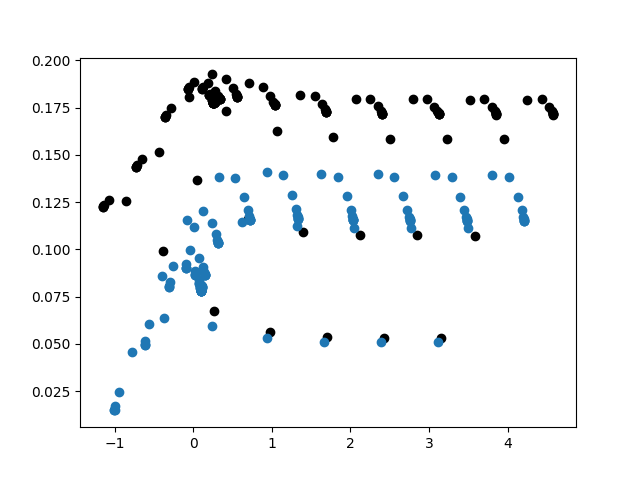

In [320]:
fig, ax = plt.subplots()
ax.scatter(c_ratio, cc_r2, color='black')
ax.scatter(sw_ratio, swc_r2, color='tab:blue')

In [321]:
ctop_ratio, ctop_r2, cidxs, cedges = get_top_models(c_ratio, cl_r2, num_bins=10)
swtop_ratio, swtop_r2, swidxs, _ = get_top_models(sw_ratio, swl_r2, num_bins=10)
cwtop_ratio, cwtop_r2, cwidxs, _ = get_top_models(cw_ratio, cwl_r2, num_bins=10)
ltop_ratio, ltop_r2, lidxs, _ = get_top_models(l_ratio, ll_r2, num_bins=10)

cmax = np.argmax(ctop_r2)
swmax = np.argmax(swtop_r2)
cwmax = np.argmax(cwtop_r2)
lmax = np.argmax(ltop_r2)

[-0.65326584 -0.05324521  0.41381916  0.89200493  1.54426195  2.25525474
  2.79572364  2.97937555  3.70605424  4.43321552]
[-0.56433053 -0.08475296  0.32283676  0.93332356  1.14148221  1.63169194
  2.35313662  3.07929923  3.28758677  3.80636345]
[-0.5600951  -0.0446757   0.48985713  0.88855529  1.09400111  1.79191125
  2.51334919  3.03405908  3.23951602  3.96658113]
[-2.55496888 -1.6484306  -0.75930653  0.02295403  0.62215653  2.02977003
  2.75540447  3.48236848  4.93684517  5.66411586]


In [322]:
isclose_list=[]
for temp in swtop_r2:
    isclose_list.append(math.isclose(swl_pos_asymps, temp, rel_tol=.03))

In [323]:
isclose_list

[False, False, False, False, False, True, True, True, True, True]

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


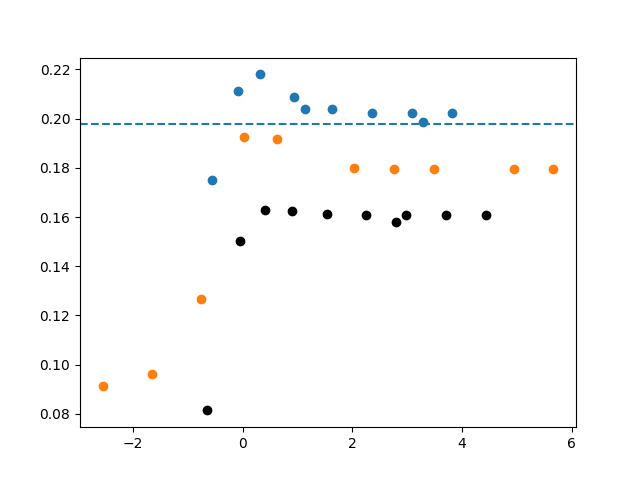

In [324]:
fig, ax = plt.subplots()
ax.scatter(ctop_ratio, ctop_r2, color='black')
ax.scatter(swtop_ratio, swtop_r2, color='tab:blue')
ax.scatter(ltop_ratio, ltop_r2, color='tab:orange')
ax.axhline(swl_pos_asymps, linestyle='--', color='tab:blue')
#@ax.set_xlim(-2,4)

In [244]:
c_harray, cw_harray, sw_harray, l_harray= squeezer(c_hlist, cw_hlist, sw_hlist, l_hlist)
c_harray = c_harray[cidxs,:,:]
cw_harray = cw_harray[cwidxs,:,:]
l_harray = l_harray[lidxs,:,:]
sw_harray = sw_harray[swidxs,:,:]

#h0 = c_harray[cmax,:,:]
h1 = c_harray[swmax,:,:]
#h1 = cw_harray[2,:,:]
h2 = sw_harray[swmax,:,:]

In [245]:
varz = np.var(Y_l, axis=0)
h1_col = collapse_h(h1, nlags=nlags, var=varz, bias=True)
h2_col = collapse_h(h2, nlags=nlags, var=varz, bias=True)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 0, 'PCs')

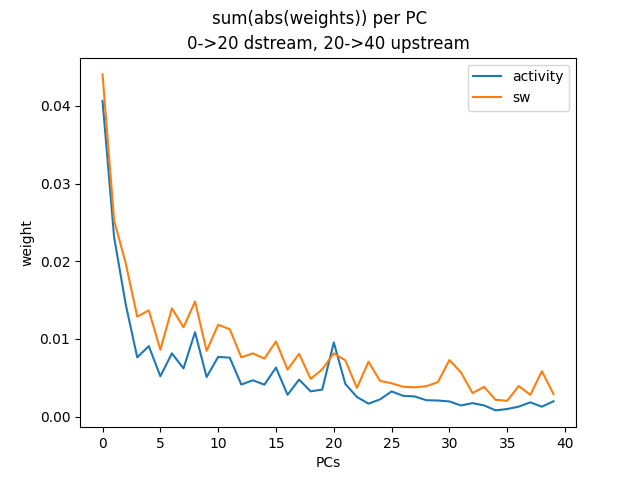

In [246]:
fig, ax = plt.subplots()
ax.plot(h1_col, label=f'activity')
ax.plot(h2_col, label=f'sw')
ax.legend()
fig.suptitle('sum(abs(weights)) per PC')
ax.set_title('0->20 dstream, 20->40 upstream')
ax.set_ylabel('weight')
ax.set_xlabel('PCs')

In [247]:
varz = np.var(Y_l, axis=0)
h1_col = collapse_h_lags(h1, nlags=nlags, var=varz, bias=True)
h2_col = collapse_h_lags(h2, nlags=nlags, var=varz, bias=True)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 0, 'lag')

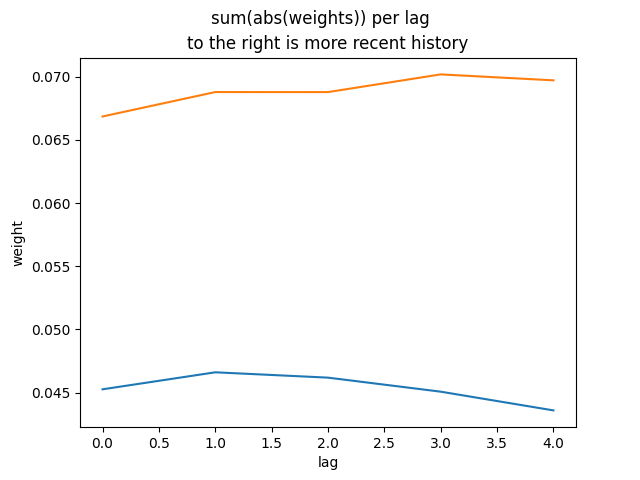

In [248]:
fig, ax = plt.subplots()
ax.plot(h1_col)
ax.plot(h2_col)
fig.suptitle('sum(abs(weights)) per lag')
ax.set_title('to the right is more recent history')
ax.set_ylabel('weight')
ax.set_xlabel('lag')

In [249]:
hs = sw_harray[swmax:,1:,0]
#h_concat = np.reshape(hs, (8, 801))
h_PCAobj = PCA(n_components=8)
h_PCA = h_PCAobj.fit_transform(hs)
print(hs.shape)

(11, 200)


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 0, 'PCs')

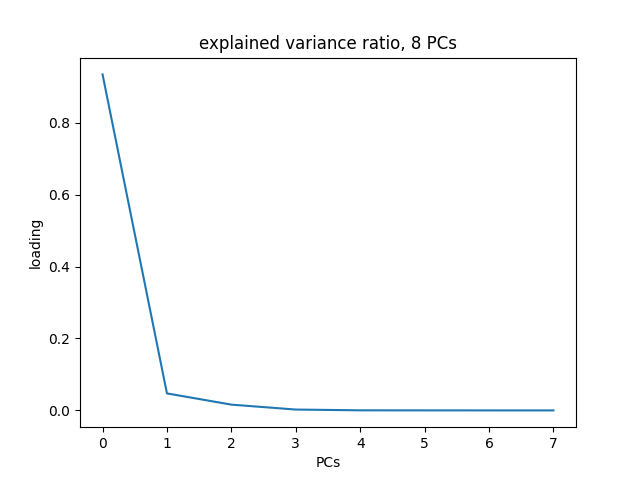

In [250]:
fig, ax = plt.subplots()
ax.plot(h_PCAobj.explained_variance_ratio_)
ax.set_title('explained variance ratio, 8 PCs')
ax.set_ylabel('loading')
ax.set_xlabel('PCs')

In [251]:
#hs = c_harray[cmax:,1:,0]
hs = c_harray[7:,1:,0]
#h_concat = np.reshape(hs, (8, 801))
h_PCAobj = PCA(n_components=8)
h_PCA = h_PCAobj.fit_transform(hs)
print(hs.shape)

(8, 200)


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 0, 'PCs')

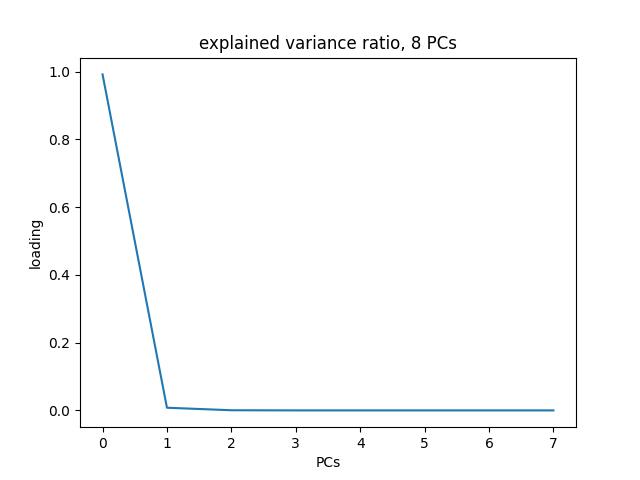

In [252]:
fig, ax = plt.subplots()
ax.plot(h_PCAobj.explained_variance_ratio_)
ax.set_title('explained variance ratio, 8 PCs')
ax.set_ylabel('loading')
ax.set_xlabel('PCs')

# plot trial averaged data

In [253]:
pre=nlags*binsize
binsize=5
num_PCs=20



laser_bounds, ctrl_bounds = session.adjustLaserBounds(pre, post, only_climb=True)
(X, Y), PCs = session.generate_trainset(bounds=session.climbing_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
X_laser, Y_laser = session.generate_testset(PCs, laser_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
X_ctrl, Y_ctrl = session.generate_testset(PCs, ctrl_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)

num_laser_samples = int((post+25) / binsize)

In [254]:
h_sw = sw_harray[swmax,:,:]
h_c = c_harray[cmax,:,:]
h_l = l_harray[lmax,:,:]

In [255]:
yhat_l1, yhat_l2, bias_l = split_h_predics(X_laser, h_sw, nlags=nlags, num_region1=20)
yhat_c1, yhat_c2, bias_c = split_h_predics(X_ctrl, h_sw, nlags=nlags, num_region1=20)

this h has bias
this h has bias


In [256]:
yhat_l1_reshape = np.reshape(yhat_l1, (int(yhat_l1.shape[0]/num_laser_samples),num_laser_samples, yhat_l1.shape[1]))
yhat_l2_reshape = np.reshape(yhat_l2, (int(yhat_l2.shape[0]/num_laser_samples),num_laser_samples, yhat_l2.shape[1]))
ylaser_reshape = np.reshape(Y_laser, (int(Y_laser.shape[0]/num_laser_samples),num_laser_samples, Y_laser.shape[1]))


In [257]:
yhat1_avg = np.average(yhat_l1_reshape, axis=0)
yhat2_avg = np.average(yhat_l2_reshape, axis=0)
ylaser_avg = np.average(ylaser_reshape, axis=0) - bias_l

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


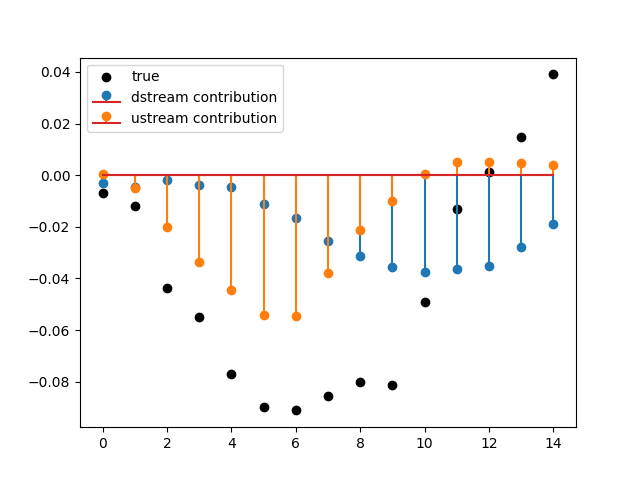

In [258]:
fig, ax = plt.subplots()
ax.stem(np.arange(num_laser_samples), yhat1_avg[:,0], label='dstream contribution')
ax.stem(np.arange(num_laser_samples), yhat2_avg[:,0], linefmt='tab:orange', label='ustream contribution')
ax.scatter(np.arange(num_laser_samples), ylaser_avg[:,0] - bias_c[0], color='black', label='true')
ax.legend()

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


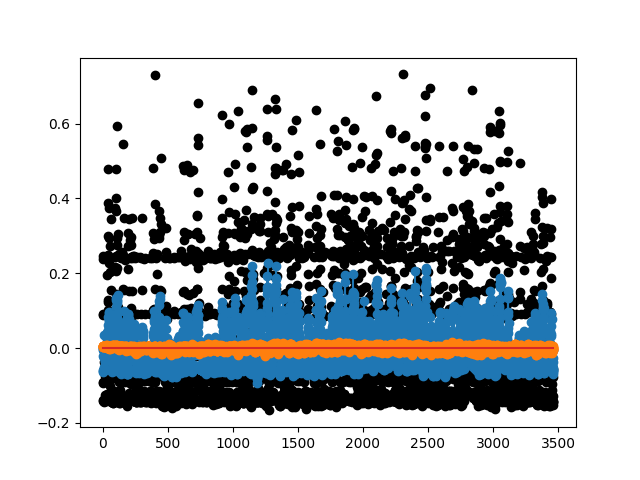

In [259]:
fig, ax = plt.subplots()
ax.stem(np.arange(yhat_c1.shape[0]), yhat_c1[:,0])
ax.stem(np.arange(yhat_c2.shape[0]), yhat_c2[:,0], linefmt='tab:orange')
ax.scatter(np.arange(Y_ctrl.shape[0]), Y_ctrl[:,0], color='black')

/tmp/ipykernel_10900/2325927372.py:1: RuntimeWarning: invalid value encountered in log10
  yhat_lratio = np.log10(np.divide(yhat_l1, yhat_l2))
/tmp/ipykernel_10900/2325927372.py:2: RuntimeWarning: invalid value encountered in log10
  yhat_cratio = np.log10(np.divide(yhat_c1, yhat_c2))
/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


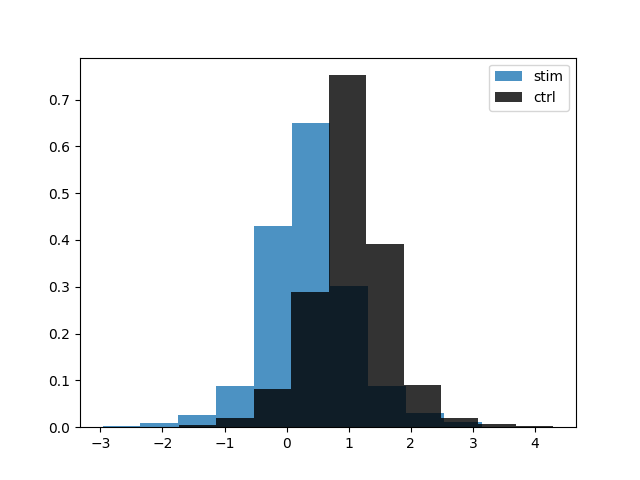

In [260]:
yhat_lratio = np.log10(np.divide(yhat_l1, yhat_l2))
yhat_cratio = np.log10(np.divide(yhat_c1, yhat_c2))
fig, ax = plt.subplots()
ax.hist(yhat_lratio[:,0], color='tab:blue', label='stim', alpha=.8, density=True)
ax.hist(yhat_cratio[:,0], color='black', label='ctrl', alpha=.8, density=True)
ax.legend()

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


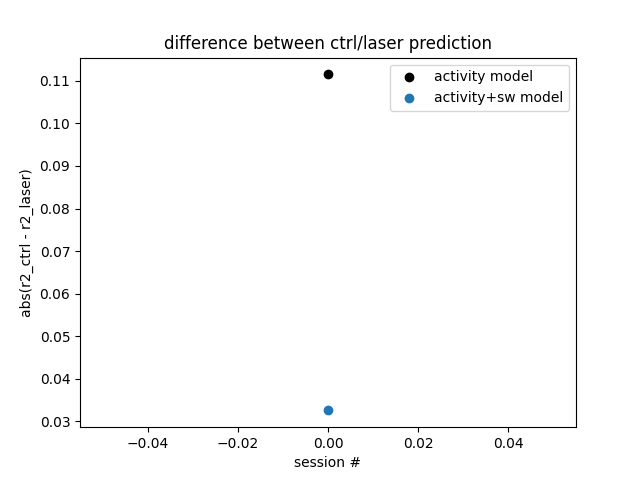

In [261]:
fig, ax = plt.subplots()
x = np.arange(len(diff_l))
ax.scatter(x, diff_c, color='black', label='activity model')
ax.scatter(x, diff_l, color='tab:blue', label='activity+sw model')
ax.set_ylabel('abs(r2_ctrl - r2_laser)')
ax.set_xlabel('session #')
ax.set_title('difference between ctrl/laser prediction')
ax.legend()

In [87]:
granger_c_avg = np.average(granger_c)
granger_c_std = np.std(granger_c)
fig, ax = plt.subplots()
ax.errorbar('1', granger_c_avg, yerr=granger_c_std, fmt='o')
ax.errorbar('1', granger_c_avg, yerr=granger_c_std, fmt='o')


NameError: name 'granger_c' is not defined

# plot covariance matrix

In [25]:
session_path = f'../data/co/co7/co7_12072023'
session = MPOptoClass(session_path)

love


In [45]:
laser_bounds, ctrl_bounds = session.adjustLaserBounds(pre=0, post=50)
omit_lbounds, _ = session.adjustLaserBounds(pre=0, post=200)
only_climbing = omitBoundInBounds(session.climbing_bounds, omit_lbounds)
reg1, reg2 = session.binner(binsize=10, bounds=only_climbing, concat=True)
reg1_l, reg2_l = session.binner(binsize=10, bounds=laser_bounds, concat=True)

In [46]:
climb = np.hstack((reg1, reg2))
laser = np.hstack((reg1_l, reg2_l))

In [47]:
laser.shape

(525, 289)

In [48]:
climb_cov = np.cov(climb, rowvar=False)
laser_cov = np.cov(laser, rowvar=False)

In [49]:
climb_cov.shape

(289, 289)

In [50]:
climb_cov

array([[ 9.29471386e-03,  3.10459222e-04, -2.39715408e-05, ...,
         1.07337242e-04,  1.70452583e-04,  3.41673233e-04],
       [ 3.10459222e-04,  6.38557605e-02,  3.25029831e-04, ...,
         4.18667924e-04,  3.26055987e-03,  6.28469126e-04],
       [-2.39715408e-05,  3.25029831e-04,  5.86471664e-03, ...,
         1.56173446e-04,  1.64267682e-04, -1.08943288e-04],
       ...,
       [ 1.07337242e-04,  4.18667924e-04,  1.56173446e-04, ...,
         3.12639654e-02,  1.21259425e-03,  9.01085336e-04],
       [ 1.70452583e-04,  3.26055987e-03,  1.64267682e-04, ...,
         1.21259425e-03,  1.25618164e-01,  5.98884794e-04],
       [ 3.41673233e-04,  6.28469126e-04, -1.08943288e-04, ...,
         9.01085336e-04,  5.98884794e-04,  2.37854364e-02]])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


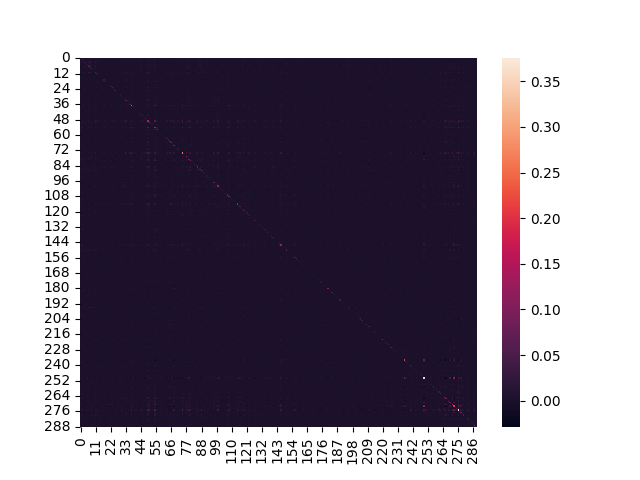

In [51]:
plt.figure()
ax=sns.heatmap(laser_cov)
plt.show()

# 

# reduced rank regression

In [52]:
session_path = f'../data/co/co7/co7_12072023'
session = MPOptoClass(session_path)

love


In [53]:
post=50
pre=100
nlags=20
binsize=5
laser_bounds, ctrl_bounds = session.adjustLaserBounds(pre=0, post=post)
omitBounds = omitBoundInBounds(session.climbing_bounds, laser_bounds)
omitBounds = omitBoundInBounds(omitBounds, ctrl_bounds)

(X, Y), PCs = session.generate_trainset(bounds=omitBounds, binsize=binsize, nlags=nlags, num_PCs=20)

bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


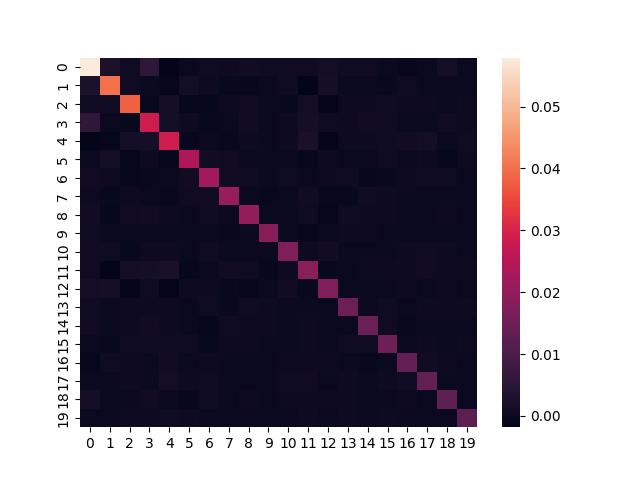

In [54]:
cov = np.cov(Y, rowvar=False)
plt.figure()
sns.heatmap(cov)
plt.show()

In [267]:
rrr = ReducedRankRidge(rank=20)
rrr.fit(X, Y)
print(rrr.rank_)
print(rrr.coef_)

20
[[ 0.00972178 -0.00051355 -0.00354741 ...  0.00045953 -0.00507518
  -0.0013452 ]
 [-0.00142904  0.01495393 -0.00222065 ...  0.00140413  0.00405199
  -0.01254376]
 [ 0.00415279  0.00058503  0.0106032  ... -0.00590908 -0.00309284
   0.00310474]
 ...
 [ 0.00112137 -0.00083029  0.00047421 ... -0.00024768 -0.00117405
  -0.004593  ]
 [-0.00095827  0.00067041  0.00129553 ...  0.0040728   0.00346024
   0.00126259]
 [ 0.00030752  0.00033177 -0.00035761 ... -0.00266338 -0.00059962
  -0.00326897]]


In [268]:
rrr.coef_.shape

(20, 800)

In [269]:
X.shape

(60455, 800)

In [271]:
rrr.intercept_

array([-0.00063315, -0.00035752,  0.00051091, -0.00056364,  0.00141755,
        0.00036433,  0.00024935,  0.00088121, -0.00091251,  0.00033167,
        0.0005984 ,  0.00072649, -0.00068273, -0.000293  , -0.00106304,
        0.00039374,  0.00063544,  0.00056467, -0.00029007, -0.00041763])

# iterating through, getting some metrics

In [3]:
output = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsAll_5nlag_50post_50sw.pickle')
asymps = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsAllasymps_5nlag_50post_50sw.pickle')

In [4]:
binsize=5
nlags=5
post=50
pre=100
num_PCs=20

In [5]:
diff_l =[]
diff_c=[]
laser_r2max=[]
sw_r2max=[]
for sesh in tqdm(np.arange(len(output))):
    cc_r2 = []
    cl_r2 = []
    c_ratio = []
    c_hlist = []

    swc_r2=[]
    swl_r2=[]
    sw_ratio=[]
    sw_hlist=[]

    cwc_r2=[]
    cwl_r2=[]
    cw_ratio=[]
    cw_hlist=[]

    lc_r2 = []
    ll_r2=[]
    l_ratio=[]
    l_hlist=[]
    regs=[]

    c_pos_asymps = asymps[sesh][0][0]
    sw_pos_asymps = asymps[sesh][0][1]
    cw_pos_asymps = asymps[sesh][0][2]
    l_pos_asymps = asymps[sesh][0][3]

    X_l = asymps[sesh][2][0]
    X_c = asymps[sesh][2][1]

    Y_l = asymps[sesh][3][0]
    Y_c = asymps[sesh][3][1]

    session_name = output[sesh][0][4][1]
    inact = output[sesh][0][4][2]

    animal = session_name.split('_')[0]
    session_path = f'../data/co/{animal}/{session_name}'
    session = MPOptoClass(session_path)


    divg_laser_bounds, divg_ctrl_bounds = session.adjustLaserBounds(pre=0, post=50, only_climb=True)
    
    dnstr_dvg=[]
    upstr_dvg=[]
    
    #(X, Y), PCs = session.generate_trainset(bounds=session.climbing_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
    #dnstr_l, upstr_l = session.binner(bounds=divg_laser_bounds, binsize=binsize, concat=True) 
    #dnstr_c, upstr_c = session.binner(bounds=divg_ctrl_bounds, binsize=binsize, concat=True) 
    
    #dnstr_dvg.append(divergence(dnstr_c, dnstr_l, PCAObject=PCs[0]))
    #print(dnstr_dvg[-1])
    #upstr_dvg.append(divergence(upstr_c, upstr_l, PCAObject=PCs[1]))
    #print(upstr_dvg[-1])
    

    num_laser_samples = int((post+25) / binsize)

    print(session_name)
    print(inact)
    for run in output[sesh]:
 

        c=run[0]
        sw=run[1]
        cw = run[2]
        l = run[3]

        regs.append(run[2][0])

        c_hlist.append(c[0])
        cl_r2.append(c[1])
        cc_r2.append(c[2])
        d, u = session.weights_per_region(c_hlist[-1], nlags=nlags, num_region1=20)
        c_ratio.append(np.log10(d/u))

        sw_hlist.append(sw[0])
        swl_r2.append(sw[1])
        swc_r2.append(sw[2])
        d, u = session.weights_per_region(sw_hlist[-1], nlags=nlags, num_region1=20)
        sw_ratio.append(np.log10(d/u))

        cw_hlist.append(cw[0])
        cwl_r2.append(cw[1])
        cwc_r2.append(cw[2])
        d, u = session.weights_per_region(cw_hlist[-1], nlags=nlags, num_region1=20)
        cw_ratio.append(np.log10(d/u))

        l_hlist.append(l[0])
        ll_r2.append(l[1])
        lc_r2.append(l[2])
        d, u = session.weights_per_region(l_hlist[-1], nlags=nlags, num_region1=20)
        l_ratio.append(np.log10(d/u))
        
    all_swmax = np.argmax(swl_r2)
    diff_l.append(np.abs(swc_r2[all_swmax]-swl_r2[all_swmax]))

    all_cmax = np.argmax(cc_r2)
    diff_c.append(np.abs(cc_r2[all_cmax]-cl_r2[all_cmax]))
    
    laser_r2max.append(np.max(ll_r2))
    sw_r2max.append(np.max(swl_r2))

  0%|                               | 0/13 [00:00<?, ?it/s]


IndexError: tuple index out of range

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


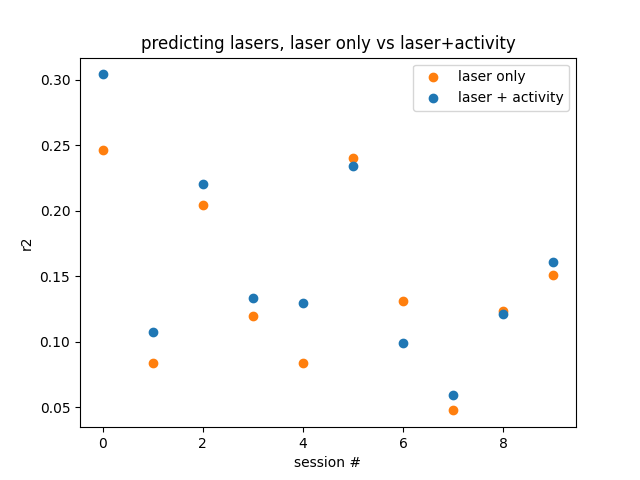

In [134]:
fig, ax = plt.subplots()
x = np.arange(len(laser_r2max))
ax.scatter(x, laser_r2max, color='tab:orange', label='laser only')
ax.scatter(x, sw_r2max, color='tab:blue', label='laser + activity')
ax.set_ylabel('r2')
ax.set_xlabel('session #')
ax.set_title('predicting lasers, laser only vs laser+activity')
ax.legend()

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


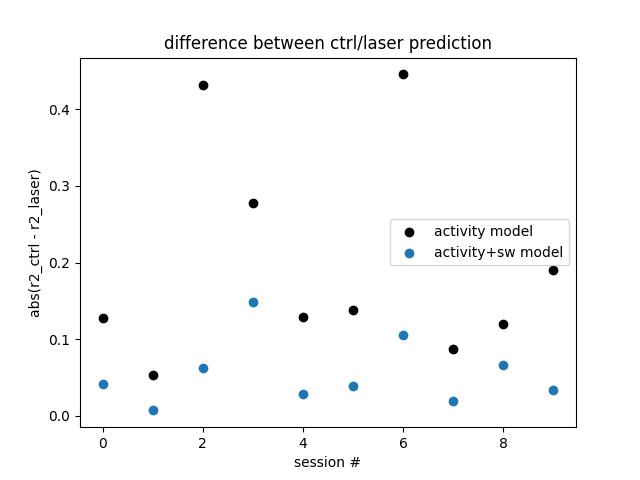

In [136]:
fig, ax = plt.subplots()
x = np.arange(len(diff_l))
ax.scatter(x, diff_c, color='black', label='activity model')
ax.scatter(x, diff_l, color='tab:blue', label='activity+sw model')
ax.set_ylabel('abs(r2_ctrl - r2_laser)')
ax.set_xlabel('session #')
ax.set_title('difference between ctrl/laser prediction')
ax.legend()

In [122]:
granger_l

[0.041113091977395655,
 0.00722790077304622,
 0.06273018981548309,
 0.0265964340710136,
 0.08603448887759568,
 0.1775453248837608,
 0.149077505806573,
 0.028474626839814388,
 0.038581603362944084,
 0.10557852613085825,
 0.019583522862546533,
 0.06602613479264015,
 0.03380812032363656]

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


<ErrorbarContainer object of 3 artists>

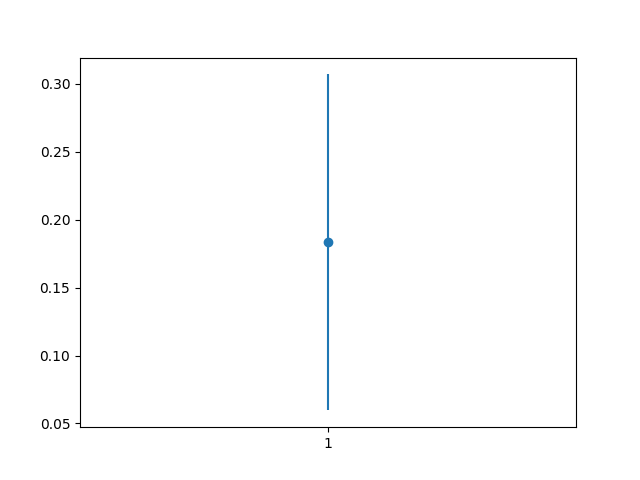

In [120]:
granger_c_avg = np.average(granger_c)
granger_c_std = np.std(granger_c)
fig, ax = plt.subplots()
ax.errorbar('1', granger_c_avg, yerr=granger_c_std, fmt='o')
ax.errorbar('1', granger_c_avg, yerr=granger_c_std, fmt='o')


# all check

In [286]:
output = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsAll_20nlag_50post_50sw.pickle')
asymps = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsAllasymps_20nlag_50post_50sw.pickle')

In [287]:
len(output)

13

In [291]:
nlags=20
binsize=5
post=50

In [292]:

cc_r2 = []
cl_r2 = []
c_ratio = []
c_hlist = []

swc_r2=[]
swl_r2=[]
sw_ratio=[]
sw_hlist=[]

cwc_r2=[]
cwl_r2=[]
cw_ratio=[]
cw_hlist=[]

lc_r2 = []
ll_r2=[]
l_ratio=[]
l_hlist=[]

#4, 
sesh=6

regs=[]

c_pos_asymps = asymps[sesh][0][0]
sw_pos_asymps = asymps[sesh][0][1]
cw_pos_asymps = asymps[sesh][0][2]
l_pos_asymps = asymps[sesh][0][3]

X_l = asymps[sesh][2][0]
X_c = asymps[sesh][2][1]

Y_l = asymps[sesh][3][0]
Y_c = asymps[sesh][3][1]

session_name = output[sesh][0][4][1]
inact = output[sesh][0][4][2]

animal = session_name.split('_')[0]
session_path = f'../data/co/{animal}/{session_name}'
session = MPOptoClass(session_path)
print(session_name)
print(inact)
for run in output[sesh]:
    
    c=run[0]
    sw=run[1]
    cw = run[2]
    l = run[3]
    
    regs.append(run[2][0])
    
    c_hlist.append(c[0])
    cl_r2.append(c[1])
    cc_r2.append(c[2])
    d, u = session.weights_per_region(c_hlist[-1], nlags=nlags, num_region1=20)
    c_ratio.append(np.log10(d/u))
    
    sw_hlist.append(sw[0])
    swl_r2.append(sw[1])
    swc_r2.append(sw[2])
    d, u = session.weights_per_region(sw_hlist[-1], nlags=nlags, num_region1=20)
    sw_ratio.append(np.log10(d/u))
    
    cw_hlist.append(cw[0])
    cwl_r2.append(cw[1])
    cwc_r2.append(cw[2])
    d, u = session.weights_per_region(cw_hlist[-1], nlags=nlags, num_region1=20)
    cw_ratio.append(np.log10(d/u))
    
    l_hlist.append(l[0])
    ll_r2.append(l[1])
    lc_r2.append(l[2])
    d, u = session.weights_per_region(l_hlist[-1], nlags=nlags, num_region1=20)
    l_ratio.append(np.log10(d/u))



love
co7_12062023
CFA


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


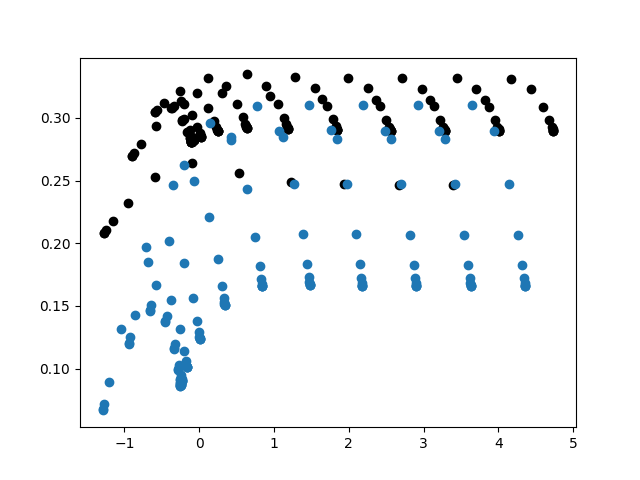

In [293]:
fig, ax = plt.subplots()
ax.scatter(c_ratio, cc_r2, color='black')
ax.scatter(sw_ratio, swc_r2, color='tab:blue')

In [294]:
ctop_ratio, ctop_r2, cidxs, cedges = get_top_models(c_ratio, cl_r2, num_bins=15)
swtop_ratio, swtop_r2, swidxs, _ = get_top_models(sw_ratio, swl_r2, num_bins=15)
cwtop_ratio, cwtop_r2, cwidxs, _ = get_top_models(cw_ratio, cwl_r2, num_bins=15)
ltop_ratio, ltop_r2, lidxs, _ = get_top_models(l_ratio, ll_r2, num_bins=15)

cmax = np.argmax(ctop_r2)
swmax = np.argmax(swtop_r2)
cwmax = np.argmax(cwtop_r2)
lmax = np.argmax(ltop_r2)

[-0.89692923 -0.56419837 -0.09365073  0.19644322  0.58181934  1.04975248
  1.13022324  1.5455156   2.25321529  2.41781376  2.97647889  3.14147152
  3.70298676  4.16743635  4.43011573]
[-1.04063799 -0.70621638 -0.35667205 -0.06974109  0.42941659  0.63389454
  1.06180919  1.47270343  1.76287916  2.19402984  2.48463175  3.21084541
  3.4187967   3.93791874  4.1458795 ]
[-0.89598051 -0.57106531 -0.20893055  0.13118018  0.40470925  0.75943056
  1.03717169  1.45527175  1.73639768  2.17521943  2.4573586   2.90105232
  3.18339785  3.62805278  4.10328645]
[-3.38746681 -2.42562493 -1.97218894 -1.07452377 -0.23100224  0.14362022
  0.77019721  1.46394187  2.1836113   2.90940189  3.63639484  4.36361504
  5.09087792  5.81814881  6.15417663]


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


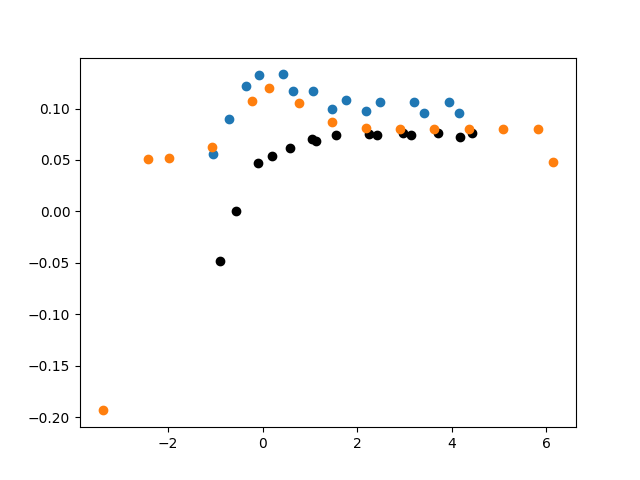

In [295]:
fig, ax = plt.subplots()
ax.scatter(ctop_ratio, ctop_r2, color='black')
ax.scatter(swtop_ratio, swtop_r2, color='tab:blue')
ax.scatter(ltop_ratio, ltop_r2, color='tab:orange')
#@ax.set_xlim(-2,4)

In [296]:
c_harray, cw_harray, sw_harray, l_harray= squeezer(c_hlist, cw_hlist, sw_hlist, l_hlist)
c_harray = c_harray[cidxs,:,:]
cw_harray = cw_harray[cwidxs,:,:]
l_harray = l_harray[lidxs,:,:]
sw_harray = sw_harray[swidxs,:,:]

#h0 = c_harray[cmax,:,:]
h1 = c_harray[swmax,:,:]
#h1 = cw_harray[2,:,:]
h2 = sw_harray[swmax,:,:]

In [297]:
varz = np.var(Y_l, axis=0)
h1_col = collapse_h(h1, nlags=nlags, var=varz, bias=True)
h2_col = collapse_h(h2, nlags=nlags, var=varz, bias=True)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 0, 'PCs')

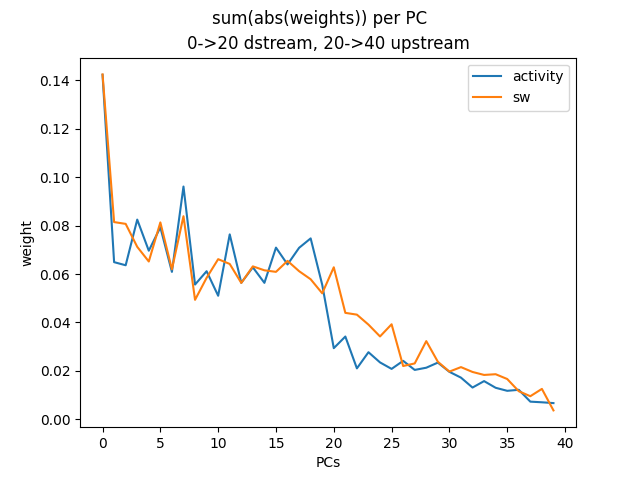

In [298]:
fig, ax = plt.subplots()
ax.plot(h1_col, label=f'activity')
ax.plot(h2_col, label=f'sw')
ax.legend()
fig.suptitle('sum(abs(weights)) per PC')
ax.set_title('0->20 dstream, 20->40 upstream')
ax.set_ylabel('weight')
ax.set_xlabel('PCs')

In [299]:
varz = np.var(Y_l, axis=0)
h1_col = collapse_h_lags(h1, nlags=nlags, var=varz, bias=True)
h2_col = collapse_h_lags(h2, nlags=nlags, var=varz, bias=True)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 0, 'lag')

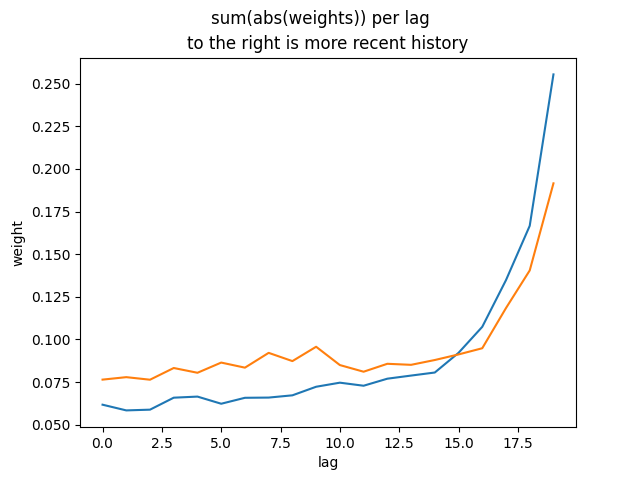

In [300]:
fig, ax = plt.subplots()
ax.plot(h1_col)
ax.plot(h2_col)
fig.suptitle('sum(abs(weights)) per lag')
ax.set_title('to the right is more recent history')
ax.set_ylabel('weight')
ax.set_xlabel('lag')

In [301]:
hs = sw_harray[swmax:,1:,0]
#h_concat = np.reshape(hs, (8, 801))
h_PCAobj = PCA(n_components=8)
h_PCA = h_PCAobj.fit_transform(hs)
print(hs.shape)

(11, 800)


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 0, 'PCs')

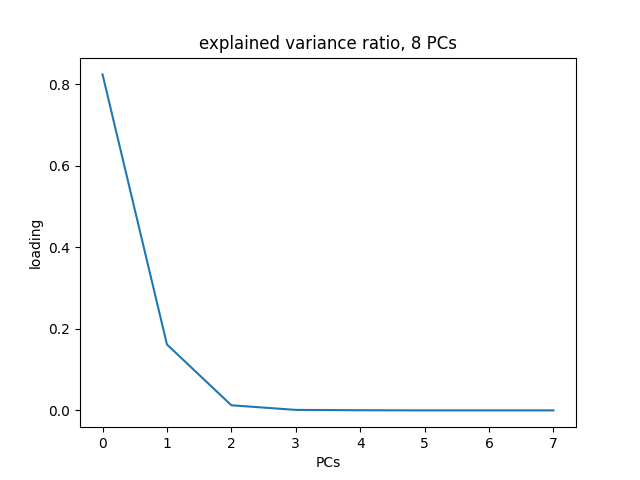

In [302]:
fig, ax = plt.subplots()
ax.plot(h_PCAobj.explained_variance_ratio_)
ax.set_title('explained variance ratio, 8 PCs')
ax.set_ylabel('loading')
ax.set_xlabel('PCs')

In [303]:
#hs = c_harray[cmax:,1:,0]
hs = c_harray[7:,1:,0]
#h_concat = np.reshape(hs, (8, 801))
h_PCAobj = PCA(n_components=8)
h_PCA = h_PCAobj.fit_transform(hs)
print(hs.shape)

(8, 800)


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 0, 'PCs')

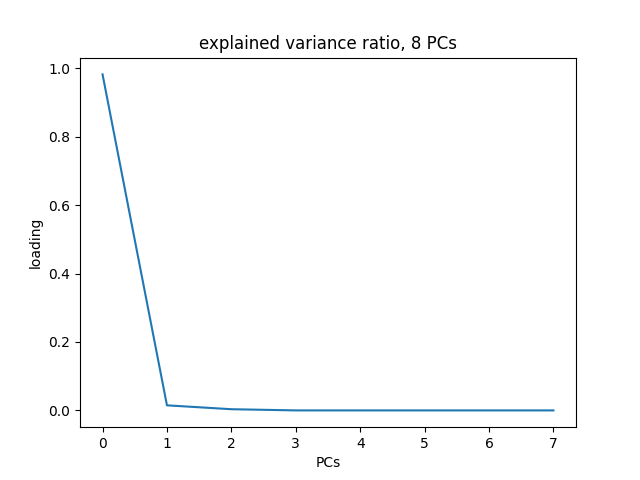

In [304]:
fig, ax = plt.subplots()
ax.plot(h_PCAobj.explained_variance_ratio_)
ax.set_title('explained variance ratio, 8 PCs')
ax.set_ylabel('loading')
ax.set_xlabel('PCs')

# plot trial averaged data

In [305]:
pre=100
binsize=5
num_PCs=20



laser_bounds, ctrl_bounds = session.adjustLaserBounds(pre, post, only_climb=True)
(X, Y), PCs = session.generate_trainset(bounds=session.climbing_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
X_laser, Y_laser = session.generate_testset(PCs, laser_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
X_ctrl, Y_ctrl = session.generate_testset(PCs, ctrl_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)

num_laser_samples = int((post+25) / binsize)

In [306]:
h_sw = sw_harray[swmax,:,:]
h_c = c_harray[cmax,:,:]
h_l = l_harray[lmax,:,:]

In [307]:
yhat_l1, yhat_l2, bias_l = split_h_predics(X_laser, h_sw, nlags=nlags, num_region1=20)
yhat_c1, yhat_c2, bias_c = split_h_predics(X_ctrl, h_sw, nlags=nlags, num_region1=20)

this h has bias
this h has bias


In [308]:
yhat_l1_reshape = np.reshape(yhat_l1, (int(yhat_l1.shape[0]/num_laser_samples),num_laser_samples, yhat_l1.shape[1]))
yhat_l2_reshape = np.reshape(yhat_l2, (int(yhat_l2.shape[0]/num_laser_samples),num_laser_samples, yhat_l2.shape[1]))
ylaser_reshape = np.reshape(Y_laser, (int(Y_laser.shape[0]/num_laser_samples),num_laser_samples, Y_laser.shape[1]))


In [309]:
yhat1_avg = np.average(yhat_l1_reshape, axis=0)
yhat2_avg = np.average(yhat_l2_reshape, axis=0)
ylaser_avg = np.average(ylaser_reshape, axis=0) - bias_l

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


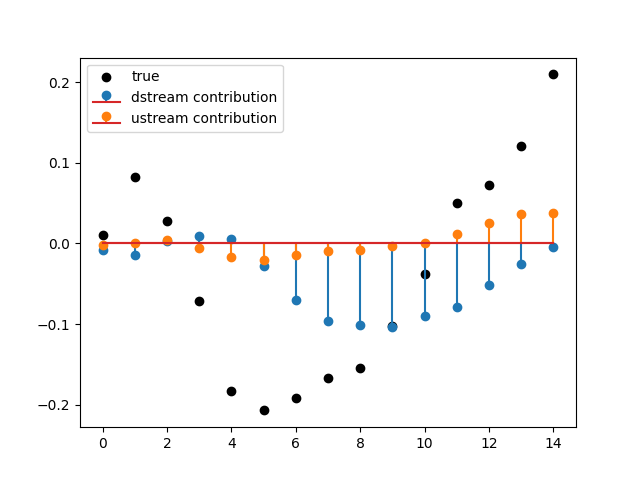

In [310]:
fig, ax = plt.subplots()
ax.stem(np.arange(num_laser_samples), yhat1_avg[:,0], label='dstream contribution')
ax.stem(np.arange(num_laser_samples), yhat2_avg[:,0], linefmt='tab:orange', label='ustream contribution')
ax.scatter(np.arange(num_laser_samples), ylaser_avg[:,0] - bias_c[0], color='black', label='true')
ax.legend()

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


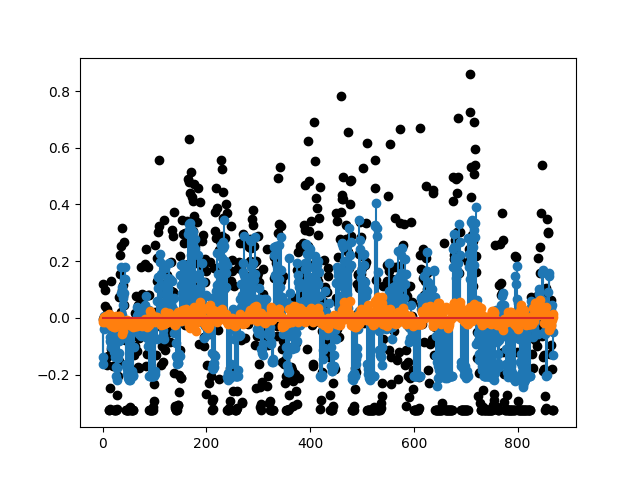

In [311]:
fig, ax = plt.subplots()
ax.stem(np.arange(yhat_c1.shape[0]), yhat_c1[:,0])
ax.stem(np.arange(yhat_c2.shape[0]), yhat_c2[:,0], linefmt='tab:orange')
ax.scatter(np.arange(Y_ctrl.shape[0]), Y_ctrl[:,0], color='black')

/tmp/ipykernel_7744/2325927372.py:1: RuntimeWarning: invalid value encountered in log10
  yhat_lratio = np.log10(np.divide(yhat_l1, yhat_l2))
/tmp/ipykernel_7744/2325927372.py:2: RuntimeWarning: invalid value encountered in log10
  yhat_cratio = np.log10(np.divide(yhat_c1, yhat_c2))
/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


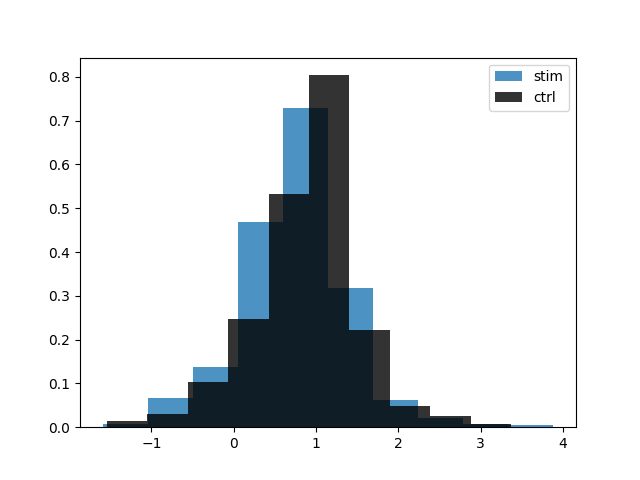

In [312]:
yhat_lratio = np.log10(np.divide(yhat_l1, yhat_l2))
yhat_cratio = np.log10(np.divide(yhat_c1, yhat_c2))
fig, ax = plt.subplots()
ax.hist(yhat_lratio[:,0], color='tab:blue', label='stim', alpha=.8, density=True)
ax.hist(yhat_cratio[:,0], color='black', label='ctrl', alpha=.8, density=True)
ax.legend()

# TO stuff

In [70]:
output = pload('/home/diya/Documents/mp_opto/picklejar/toSweepRegsAll_2nlag_24post_50sw.pickle')
asymps = pload('/home/diya/Documents/mp_opto/picklejar/toSweepRegsAllasymps_2nlag_24post_50sw.pickle')

# load

In [73]:
cc_r2 = []
c_ratio = []
cl_r2=[]

swc_r2 = []
sw_ratio = []
swl_r2=[]

lc_r2=[]
ll_r2=[]
l_ratio =[]

c_hlist =[]
sw_hlist = []
l_hlist = []

sesh=0

regs=[]

c_asymps = asymps[sesh][0][0]
sw_asymps = asymps[sesh][0][1]
laser_asymps = asymps[sesh][0][2]

X_l = asymps[sesh][2][0]
X_c = asymps[sesh][2][1]

Y_l = asymps[sesh][3][0]
Y_c = asymps[sesh][3][1]

session_name = output[sesh][0][3][1]
inact = output[sesh][0][3][2]


animal = session_name.split('_')[0]
session_path = f'../data/to/{animal}/{session_name}'
session = MPOptoClass(session_path)
print(session_name)

for idx, run in enumerate(output[sesh]):
    c=run[0]
    sw=run[1]
    l = run[2]
    
   
    c_hlist.append(c[0])
    d, u = session.weights_per_region(c_hlist[-1], nlags=2, num_region1=20)
    c_ratio.append(np.log10(d/u))
    cl_r2.append(c[1])
    cc_r2.append(c[2])
    
    sw_hlist.append(sw[0])
    d, u = session.weights_per_region(sw_hlist[-1], nlags=2, num_region1=20)
    sw_ratio.append(np.log10(d/u))
    swl_r2.append(sw[1])
    swc_r2.append(sw[2])
    
    l_hlist.append(l[0])
    d, u = session.weights_per_region(l_hlist[-1], nlags=2, num_region1=20)
    l_ratio.append(np.log10(d/u))
    ll_r2.append(l[1])
    lc_r2.append(l[2])
    

masking THAL, 300<x<1000
love
to5_06202024


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


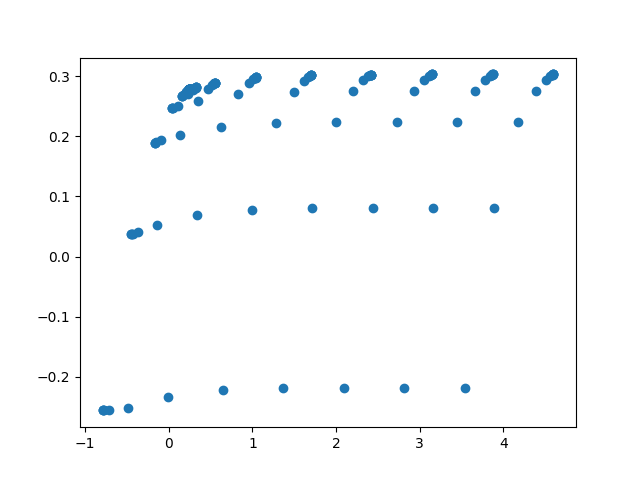

In [74]:
fig, ax = plt.subplots()
ax.scatter(c_ratio, cl_r2)

In [75]:
ctop_ratio, ctop_r2, cidxs, cedges = get_top_models(c_ratio, cc_r2, num_bins=15)
swtop_ratio, swtop_r2, swidxs, _ = get_top_models(sw_ratio, swc_r2, num_bins=15)
ltop_ratio, ltop_r2, lidxs, _ = get_top_models(l_ratio, lc_r2, num_bins=15)
cmax = np.argmax(ctop_r2)
swmax = np.argmax(swtop_r2)
lmax = np.argmax(ltop_r2)

[-0.44435921 -0.0873326   0.11546836  0.34379363  0.83292165  1.28559931
  1.49176885  1.99823576  2.20455135  2.72268829  2.92904102  3.44942983
  3.65578963  4.17660293  4.38296406]
[-0.43263569 -0.1077808   0.08146415  0.51570923  0.6953234   1.14318184
  1.32513584  1.84727555  2.02994135  2.56998187  2.75279798  3.29639088
  3.47923461  4.02350147  4.2063504 ]
[-2.73976904 -2.29034307 -1.42708126 -0.69885642 -0.0754249   0.49044461
  1.17462314  1.89298189  2.6185539   2.80752871  3.34550704  4.07271984
  4.79998134  5.52725196  6.2545243 ]


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


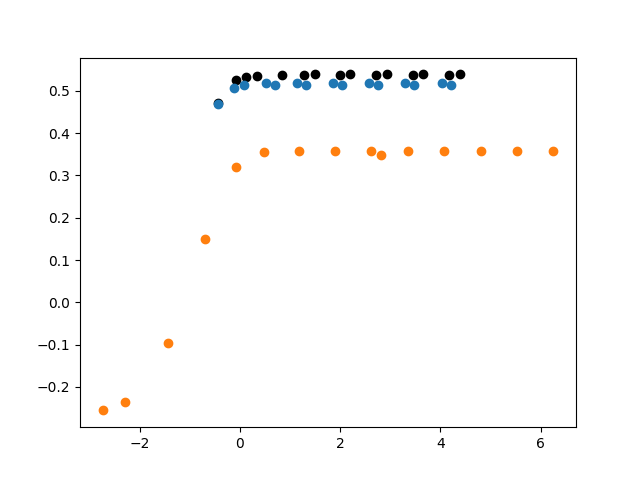

In [76]:
fig, ax = plt.subplots()
ax.scatter(ctop_ratio, ctop_r2, color='black')
ax.scatter(swtop_ratio, swtop_r2, color='tab:blue')
ax.scatter(ltop_ratio, ltop_r2, color='tab:orange')
#@ax.set_xlim(-2,4)

In [86]:
c_harray, sw_harray, l_harray = squeezer(c_hlist, sw_hlist, l_hlist)
c_harray = c_harray[cidxs,:,:]
sw_harray = sw_harray[swidxs,:,:]
l_harray = l_harray[lidxs,:,:]

h1 = c_harray[3,:,:]
h2 = sw_harray[3,:,:]
#h3 = l_harray[lmax,:,:]

In [87]:
nlags=2
varz = np.var(Y_l, axis=0)
h1_col = collapse_h(h1, nlags=nlags, var=varz, bias=True)
h2_col = collapse_h(h2, nlags=nlags, var=varz, bias=True)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 0, 'PCs')

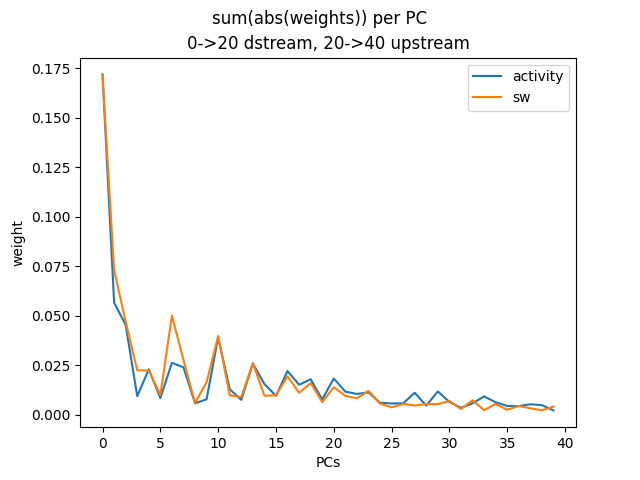

In [88]:
fig, ax = plt.subplots()
ax.plot(h1_col, label=f'activity')
ax.plot(h2_col, label=f'sw')
ax.legend()
fig.suptitle('sum(abs(weights)) per PC')
ax.set_title('0->20 dstream, 20->40 upstream')
ax.set_ylabel('weight')
ax.set_xlabel('PCs')

In [89]:
varz = np.var(Y_l, axis=0)
h1_col = collapse_h_lags(h1, nlags=nlags, var=varz, bias=True)
h2_col = collapse_h_lags(h2, nlags=nlags, var=varz, bias=True)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 0, 'lag')

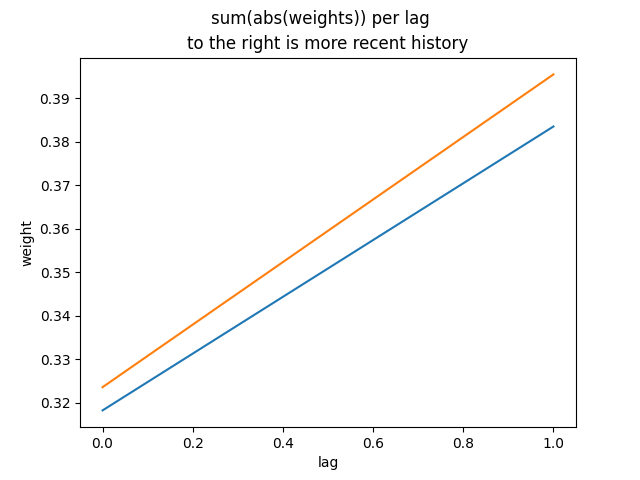

In [90]:
fig, ax = plt.subplots()
ax.plot(h1_col)
ax.plot(h2_col)
fig.suptitle('sum(abs(weights)) per lag')
ax.set_title('to the right is more recent history')
ax.set_ylabel('weight')
ax.set_xlabel('lag')

In [96]:
pre=10
post=24
binsize=5
nlags=2
num_PCs=20

laser_bounds, ctrl_bounds = session.adjustLaserBounds(pre, post, only_climb=True)
if session.num_powers==5:
    power_mask = session.getPowers(bounds=laser_bounds, num_powers=5, 
                                   pre=pre, post=post)
    omit_lasers = laser_bounds[power_mask<4,:]
    laser_bounds = laser_bounds[power_mask>=4,:]
else:
    power_mask = session.getPowers(bounds=laser_bounds, num_powers=2, 
                                   pre=pre, post=post)
    omit_lasers = laser_bounds[power_mask==1,:]
    laser_bounds = laser_bounds[power_mask==2,:]

omitLaserBounds = omitBoundInBounds(session.climbing_bounds, omit_lasers)
omitLaserBounds = omitBoundInBounds(omitLaserBounds, ctrl_bounds)
omitLaserBounds = minimumBoundSize(omitLaserBounds, min_size = post+pre) 

(X, Y), PCs = session.generate_trainset(bounds=omitLaserBounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
X_laser, Y_laser = session.generate_testset(PCs, laser_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
X_ctrl, Y_ctrl = session.generate_testset(PCs, ctrl_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)

In [97]:
h_sw = sw_harray[swmax,:,:]
h_c = c_harray[cmax,:,:]
h_l = l_harray[lmax,:,:]

In [98]:
yhat_l1, yhat_l2, bias_l = split_h_predics(X_laser, h_sw, nlags=nlags, num_region1=20)
yhat_c1, yhat_c2, bias_c = split_h_predics(X_ctrl, h_sw, nlags=nlags, num_region1=20)

this h has bias
this h has bias


In [100]:
num_laser_samples = int((post+31) / binsize)
yhat_l1_reshape = np.reshape(yhat_l1, (int(yhat_l1.shape[0]/num_laser_samples),num_laser_samples, yhat_l1.shape[1]))
yhat_l2_reshape = np.reshape(yhat_l2, (int(yhat_l2.shape[0]/num_laser_samples),num_laser_samples, yhat_l2.shape[1]))
ylaser_reshape = np.reshape(Y_laser, (int(Y_laser.shape[0]/num_laser_samples),num_laser_samples, Y_laser.shape[1]))


In [101]:
yhat1_avg = np.average(yhat_l1_reshape, axis=0)
yhat2_avg = np.average(yhat_l2_reshape, axis=0)
ylaser_avg = np.average(ylaser_reshape, axis=0) - bias_l

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


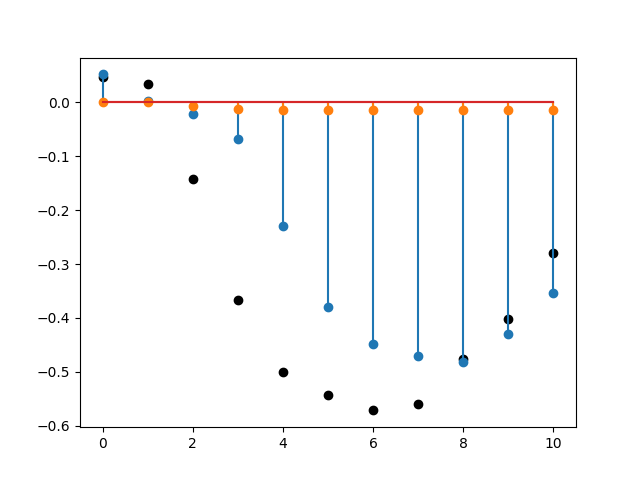

In [103]:
fig, ax = plt.subplots()
ax.stem(np.arange(num_laser_samples), yhat1_avg[:,0])
ax.stem(np.arange(num_laser_samples), yhat2_avg[:,0], linefmt='tab:orange')
ax.scatter(np.arange(num_laser_samples), ylaser_avg[:,0], color='black')

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


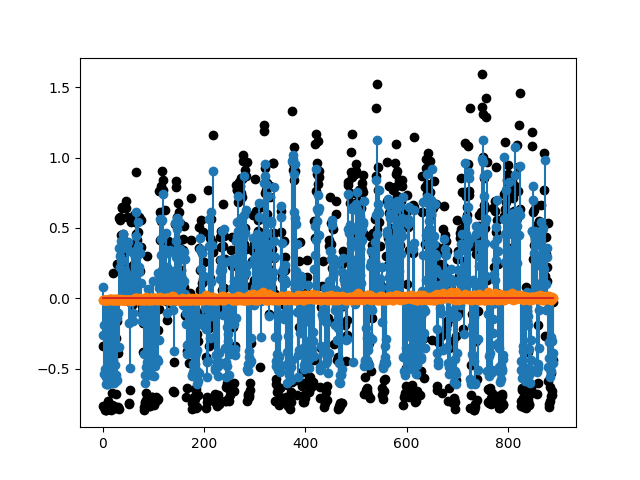

In [104]:
fig, ax = plt.subplots()
ax.stem(np.arange(yhat_c1.shape[0]), yhat_c1[:,0])
ax.stem(np.arange(yhat_c2.shape[0]), yhat_c2[:,0], linefmt='tab:orange')
ax.scatter(np.arange(Y_ctrl.shape[0]), Y_ctrl[:,0], color='black')

/tmp/ipykernel_7744/3118899073.py:1: RuntimeWarning: invalid value encountered in log10
  yhat_lratio = np.log10(np.divide(yhat_l1, yhat_l2))
/tmp/ipykernel_7744/3118899073.py:2: RuntimeWarning: invalid value encountered in log10
  yhat_cratio = np.log10(np.divide(yhat_c1, yhat_c2))
/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(array([0.00462983, 0.01851933, 0.0138895 , 0.05555798, 0.18519328,
        0.63428697, 0.67595546, 0.28241974, 0.1018563 , 0.03240882]),
 array([-1.44002322, -0.94119975, -0.44237628,  0.0564472 ,  0.55527067,
         1.05409414,  1.55291762,  2.05174109,  2.55056456,  3.04938804,
         3.54821151]),
 <BarContainer object of 10 artists>)

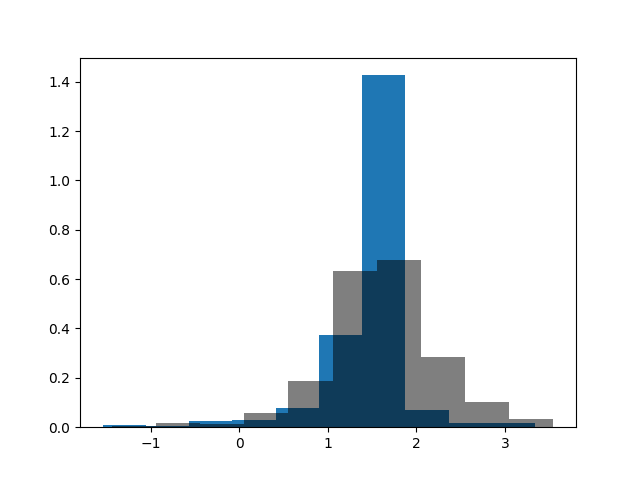

In [105]:
yhat_lratio = np.log10(np.divide(yhat_l1, yhat_l2))
yhat_cratio = np.log10(np.divide(yhat_c1, yhat_c2))
fig, ax = plt.subplots()
ax.hist(yhat_lratio[:,0], color='tab:blue', density=True, stacked=True,)
#ax.set_xlim(-2,1)
ax.hist(yhat_cratio[:,0], color='black', density=True, stacked=True, alpha=.5)


# for play

In [12]:
session_path = '/home/diya/Documents/mp_opto/data/co/co7/co7_12072023'
session = MPOptoClass(session_path)

love


In [13]:
print(session.num_region1)

print(session.num_region2)

227
62


In [14]:
session.subsampleNeurons(percent_region1=.5)

new num region1: 113
new num region2: 31


In [15]:
a, b= session.binner(binsize=100)

In [16]:
a.shape

(37850, 113)

In [17]:
b.shape

(37850, 31)